In [2]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("csv/morganfeatures_3d_train.csv")

df1 = pd.read_csv("csv/newSMILES_plus_Trainingdata.csv")

df = df.dropna()
df1 = df1.drop(["Unnamed: 0", "Unnamed: 0.1"], axis = 1)

y = np.array(df1["Tm"])
X = np.array(df1.drop(["Tm", "SMILES"], axis = 1))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3)

y

array([-181.15, -227.15, -240.15, ..., -171.65, -172.15, -345.75],
      shape=(28232,))

In [22]:
w = np.where(y_train > 400, 2.0, 1.0)

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
y_tr_t = pt.fit_transform(y_train.reshape(-1,1)).ravel()




model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:absoluteerror",
    tree_method="hist",
    random_state=22
)

model.fit(X_train, y_train, verbose=False) 
pred_test = model.predict(X_test)

#Mit Powertransformer

# model.fit(X_train, y_tr_t, sample_weight=w)
# pred = pt.inverse_transform(
#     model.predict(X_test).reshape(-1,1)
# ).ravel()


In [23]:
np.mean(np.abs(pred_test - y_test))

np.float64(22.009949096154998)

In [24]:
testSet = pd.read_csv("melting-point-data/morganfeatures_test.csv")
testSetready = testSet.drop(["Unnamed: 0", "id", "SMILES"], axis=1)

testSetready.shape
df1

,Tm,SMILES,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,-181.15,c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],10.949337,10.949337,0.259075,-0.655211,0.619888,10.105263,259.221,250.149,...,0,1,1,0,1,1,1,1,1,0
1,-227.15,c1ccc(c(c1)N)N2CCCCC2,5.909724,5.909724,0.906852,0.906852,0.664933,17.384615,176.263,160.135,...,0,1,0,0,1,1,1,0,1,0
2,-240.15,c1cnc(nc1)N2CCNCC2,4.189444,4.189444,0.846296,0.846296,0.628312,17.833333,164.212,152.116,...,0,1,0,0,1,1,1,0,1,0
3,-148.15,c1ccc(c(c1)N2CCNCC2)O,9.600688,9.600688,0.379074,0.379074,0.667456,17.384615,178.235,164.123,...,1,1,0,0,1,1,1,1,1,0
4,-328.15,C1CCC(=CC1)CCN,5.418520,5.418520,0.825231,0.825231,0.559754,19.444444,125.215,110.095,...,0,1,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28227,-172.65,c1ccc2c(c1)Cc3ccccc3O2,5.777407,5.777407,0.978519,0.978519,0.517522,12.571429,182.222,172.142,...,1,0,0,0,0,1,1,1,1,0
28228,-172.65,c1ccc2c(c1)Cc3ccccc3O2,5.777407,5.777407,0.978519,0.978519,0.517522,12.571429,182.222,172.142,...,1,0,0,0,0,1,1,1,1,0
28229,-171.65,c1ccc2c(c1)Cc3ccccc3O2,5.777407,5.777407,0.978519,0.978519,0.517522,12.571429,182.222,172.142,...,1,0,0,0,0,1,1,1,1,0
28230,-172.15,C1C2=CC=CC=C2OC3=CC=CC=C31,5.777407,5.777407,0.978519,0.978519,0.517522,12.571429,182.222,172.142,...,1,0,0,0,0,1,1,1,1,0


In [40]:
testSet = pd.read_csv("melting-point-data/morganfeatures_test.csv")
testSetready = testSet.drop(["Unnamed: 0", "id", "SMILES"], axis=1)

y_test_pred = model.predict(np.array(testSetready))
y_test_pred = np.array(y_test_pred)
y_testset_merge = pd.DataFrame(y_test_pred, columns=["Tm_pred"])

testSet["Tm_pred"] = y_test_pred

testSet = testSet.drop(["Unnamed: 0"], axis = 1)

model_2_pred = testSet[testSet["Tm_pred"] > 330]

model_2_pred.to_csv("testnewData.csv", index = False)

In [26]:
mae = np.mean(np.abs(pred_test - y_test))

mae



np.float64(22.009949096154998)

In [50]:
model.save_model("final.json")

TypeError: `_estimator_type` undefined.  Please use appropriate mixin to define estimator type.

In [48]:
test = pd.read_csv("melting-point-data/morganfeatures_test.csv")
test = test.drop(["Unnamed: 0"], axis=1)
# X_test_new = test.drop



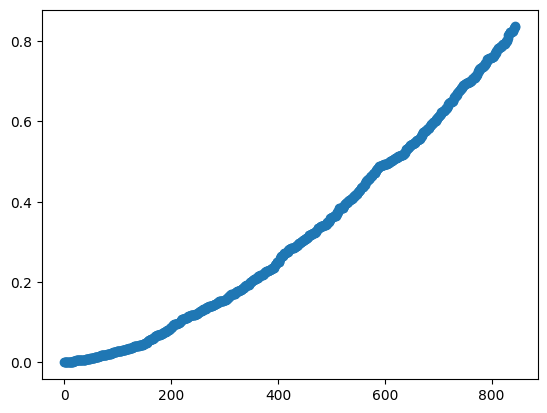

In [27]:
import matplotlib.pyplot as plt
X_test.shape
i = 845
x_axis = np.arange(0,845,1)
sorted_dev = np.sort(np.abs(pred_test-y_test))
plt.scatter(x_axis[:i], sorted_dev[:i])
# plt.scatter(x_axis[:i], y_test[:i])




In [28]:
np.mean(sorted_dev[:400])

np.float64(0.09689640941619981)

In [29]:
test = pd.read_csv("melting-point-data/morganfeatures_test.csv")

X_m_test = np.array(test.drop(["Unnamed: 0", "id", "SMILES"], axis = 1))

pred_m_test = model.predict(X_m_test)



In [30]:
submission = pd.DataFrame({"id": test["id"], "Tm": pred_m_test })

In [31]:
# submission.to_csv("submission1812.csv", index=False)

In [32]:
df

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_163,MACCS_164,MACCS_165,MACCS_166,NPR1,NPR2,Asphericity,Eccentricity,InertialShapeFactor,RadiusOfGyration
0,FC1=C(F)C(F)(F)C1(F)F,213.15,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,...,0,0,1,0,0.699649,0.700034,0.062583,0.714487,0.001976,1.936239
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,...,1,0,1,0,0.253648,0.746352,0.432068,0.967297,0.001573,2.934596
2,CCN1C(C)=Nc2ccccc12,324.15,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,...,1,0,1,0,0.350674,0.705202,0.300107,0.936498,0.002297,2.369927
3,CC#CC(=O)O,351.15,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,...,0,1,0,0,0.137891,0.871856,0.642898,0.990447,0.018629,2.014123
4,CCCCC(S)C,126.15,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,...,0,0,0,0,0.350902,0.772435,0.288697,0.936412,0.004524,2.090147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,CC(C)NCC(COC1=CC=CC=C1CC=C)O,380.15,9.772509,9.772509,0.299480,-0.496123,0.693681,12.444444,249.354,226.170,...,1,1,1,0,0.301635,0.901559,0.353236,0.953424,0.001085,3.488071
2822,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,445.15,4.317778,4.317778,0.664259,0.664259,0.703380,10.000000,210.285,192.141,...,1,0,1,0,0.505514,0.505515,0.241841,0.862818,0.000556,2.931861
2823,C1C2CC3CC1CC(C2)(C3)N,433.15,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,...,1,0,1,0,0.702592,0.998656,0.048270,0.711593,0.003271,1.969874
2824,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)CC1=CC=...,469.15,12.474516,12.474516,0.425409,-0.587731,0.272662,11.833333,537.576,495.240,...,1,1,1,0,0.187282,0.902797,0.541119,0.982306,0.000317,5.433674


In [33]:
basic = pd.read_csv("melting-point-data/train.csv")
basic

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,707,ClCCBr,256.45,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2658,1573,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2659,1634,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,3022,CCC(=O)c1ccc2ccccc2c1,333.15,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
analysis_df = df.copy()
df.columns


Index(['SMILES', 'Tm', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       'HeavyAtomMolWt',
       ...
       'MACCS_163', 'MACCS_164', 'MACCS_165', 'MACCS_166', 'NPR1', 'NPR2',
       'Asphericity', 'Eccentricity', 'InertialShapeFactor',
       'RadiusOfGyration'],
      dtype='object', length=2439)

In [35]:
df

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_163,MACCS_164,MACCS_165,MACCS_166,NPR1,NPR2,Asphericity,Eccentricity,InertialShapeFactor,RadiusOfGyration
0,FC1=C(F)C(F)(F)C1(F)F,213.15,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,...,0,0,1,0,0.699649,0.700034,0.062583,0.714487,0.001976,1.936239
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,...,1,0,1,0,0.253648,0.746352,0.432068,0.967297,0.001573,2.934596
2,CCN1C(C)=Nc2ccccc12,324.15,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,...,1,0,1,0,0.350674,0.705202,0.300107,0.936498,0.002297,2.369927
3,CC#CC(=O)O,351.15,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,...,0,1,0,0,0.137891,0.871856,0.642898,0.990447,0.018629,2.014123
4,CCCCC(S)C,126.15,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,...,0,0,0,0,0.350902,0.772435,0.288697,0.936412,0.004524,2.090147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,CC(C)NCC(COC1=CC=CC=C1CC=C)O,380.15,9.772509,9.772509,0.299480,-0.496123,0.693681,12.444444,249.354,226.170,...,1,1,1,0,0.301635,0.901559,0.353236,0.953424,0.001085,3.488071
2822,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,445.15,4.317778,4.317778,0.664259,0.664259,0.703380,10.000000,210.285,192.141,...,1,0,1,0,0.505514,0.505515,0.241841,0.862818,0.000556,2.931861
2823,C1C2CC3CC1CC(C2)(C3)N,433.15,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,...,1,0,1,0,0.702592,0.998656,0.048270,0.711593,0.003271,1.969874
2824,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)CC1=CC=...,469.15,12.474516,12.474516,0.425409,-0.587731,0.272662,11.833333,537.576,495.240,...,1,1,1,0,0.187282,0.902797,0.541119,0.982306,0.000317,5.433674


In [36]:
y1 = np.array(df["Tm"])
X1 = np.array(df)

X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1, test_size=0.3, random_state=42)

In [37]:
X1_test[0:4]

array([['CC[Si](Cl)(Cl)Cl', 167.55, 5.387345679012345, ...,
        0.6398556874188749, 0.0024128471163346, 1.9875978265862688],
       ['Cc1cc(N)c2ccccc2n1', 442.15, 5.8170370370370375, ...,
        0.9374725026218752, 0.0020484708271675, 2.4128928869137285],
       ['O=C(O)C(C)(C)C', 308.15, 10.020833333333332, ...,
        0.8131670885433109, 0.0054533741641709, 1.771456012774841],
       ['NCCCCCCCC', 273.15, 5.343246488410179, ..., 0.9880875051568232,
        0.0069246801071148, 2.775888122040032]],
      shape=(4, 2439), dtype=object)

In [38]:
analysis_df = pd.DataFrame(X1_test, columns = df.columns)
analysis_df["Tm_pred"] = pred_test

ValueError: Length of values (8470) does not match length of index (844)

In [ ]:
cols = list(analysis_df.columns)

# Tm und Tm_pred nebeneinander bringen
cols.remove("Tm_pred")
tm_index = cols.index("Tm")
cols.insert(tm_index + 1, "Tm_pred")

analysis_df = analysis_df[cols]


analysis_df

,SMILES,Tm,Tm_pred,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,Clc1ccc(Cl)cc1,325.85,301.349091,5.553025,5.553025,0.717037,0.717037,0.528586,9.25,147.004,...,0,0,0,0,0,1,1,0,1,0
1,C#CC(C)C,183.45,156.093918,4.921296,4.921296,0.412037,0.412037,0.374957,7.6,68.119,...,0,0,0,1,0,0,0,0,0,0
2,Nc1cccc(c1)Oc2ccccc2,310.15,334.921783,5.63225,5.63225,0.706881,0.706881,0.729582,9.714286,185.226,...,1,1,0,0,1,1,1,1,1,0
3,CCCCCC1=CCCC1,190.15,209.868698,2.440139,2.440139,1.348669,1.348669,0.410427,17.5,138.254,...,0,0,0,1,0,0,0,0,1,0
4,CNCC(=O)O,481.15,474.302979,9.536806,9.536806,0.041667,-0.821759,0.469563,8.166667,89.094,...,1,1,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,COCCOC(=O)c1ccccc1C(=O)OCCOC,228.15,318.387299,11.864498,11.864498,0.127371,-0.582091,0.528356,10.1,282.292,...,1,0,1,1,0,1,1,1,1,0
841,O=C(C)C,178.35,197.329605,9.444444,9.444444,0.166667,0.166667,0.398237,6.5,58.08,...,0,0,0,1,0,0,0,1,0,0
842,CCc1ccc(CC)cc1,230.32,222.728745,2.207176,2.207176,1.142851,1.142851,0.58312,9.8,134.222,...,0,0,0,1,0,1,1,0,1,0
843,c1ccc(cc1)Nc2ccc3ccccc3c2,381.15,385.040863,3.396037,3.396037,1.113686,1.113686,0.664651,10.352941,219.287,...,0,1,0,0,1,1,1,0,1,0


In [ ]:
analysis_df[
    ((analysis_df["Tm"] - analysis_df["Tm_pred"]) > 50) &
    (analysis_df["Tm"] > 400)
]


,SMILES,Tm,Tm_pred,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
24,C(CS(=O)(=O)O)N,585.65,374.843201,9.706806,9.706806,0.028935,-3.79919,0.455699,11.714286,125.149,...,0,1,1,0,1,0,0,1,0,0
91,O=C1CC2(C)CCC1C2(C)C,459.65,388.551666,11.456574,11.456574,0.281829,0.281829,0.520631,46.818182,152.237,...,0,0,0,1,0,0,1,1,1,0
111,C1C(C(C(C(N1)CO)O)O)O,479.15,394.160614,9.17537,9.17537,0.19787,-1.158889,0.284553,45.818182,163.173,...,1,1,1,0,1,0,1,1,1,0
158,CCCCCCCCCCCCCCCCCCCC(=O)O,673.0,574.028503,10.35968,10.35968,0.345837,-0.651889,0.273655,10.954545,312.538,...,1,0,1,1,0,0,0,1,0,0
179,CCCCCCCCC(=O)OC,486.65,342.562561,10.678445,10.678445,0.078249,-0.078249,0.435733,9.833333,172.268,...,1,0,1,1,0,0,0,1,0,0
185,Brc1ccc(cc1)N(=O)=O,400.15,337.045380,10.102475,10.102475,0.114074,-0.424167,0.517657,9.3,202.007,...,0,1,1,0,1,1,1,1,1,0
206,CCCCCCCCC(=O)OCC,500.15,278.782379,10.909695,10.909695,0.043526,-0.043526,0.429221,10.0,186.295,...,1,0,1,1,0,0,0,1,0,0
233,CCCCCCCCCC(=O)O,541.85,449.509705,10.134489,10.134489,0.341049,-0.663372,0.570683,10.083333,172.268,...,1,0,1,1,0,0,0,1,0,0
246,c1ccc2c(c1)ccc3c4ccccc4ccc23,531.35,437.006165,2.236111,2.236111,1.305816,1.305816,0.365178,11.333333,228.294,...,0,0,0,0,0,1,1,0,1,0
255,COc1ccccc1c2ccccc2OC,428.15,317.199829,5.343678,5.343678,0.853704,0.853704,0.779471,9.875,214.264,...,1,0,1,1,0,1,1,1,1,0


In [ ]:
df[df["Tm"] > 800]

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
1095,CCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCC...,897.15,12.75836,12.75836,0.061863,-0.758646,0.034615,11.368421,807.339,708.555,...,1,0,1,1,0,0,0,1,0,0


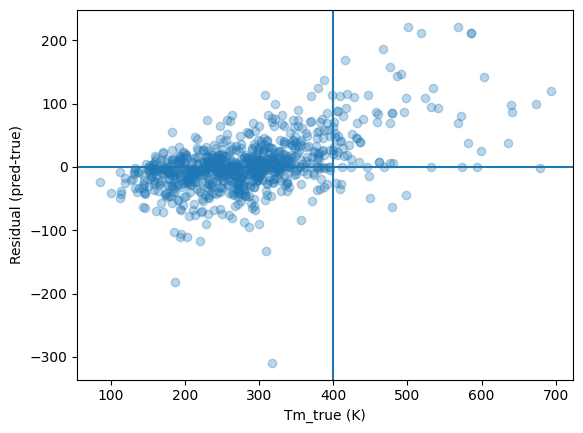

In [ ]:
import matplotlib.pyplot as plt
res = (analysis_df["Tm"] - analysis_df["Tm_pred"])



plt.scatter(analysis_df["Tm"], res, alpha=0.3)
plt.axhline(0)
plt.axvline(400)
plt.xlabel("Tm_true (K)")
plt.ylabel("Residual (pred-true)")
plt.show()



In [ ]:
df[df["Tm"] > 0]

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,FC1=C(F)C(F)(F)C1(F)F,213.15,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,...,0,0,0,0,0,0,0,0,1,0
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,...,0,0,0,0,1,1,1,0,1,0
2,CCN1C(C)=Nc2ccccc12,324.15,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,...,0,1,0,1,1,1,1,0,1,0
3,CC#CC(=O)O,351.15,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,...,1,0,1,1,0,0,0,1,0,0
4,CCCCC(S)C,126.15,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,CC(C)NCC(COC1=CC=CC=C1CC=C)O,380.15,9.772509,9.772509,0.299480,-0.496123,0.693681,12.444444,249.354,226.170,...,1,1,1,1,1,1,1,1,1,0
2822,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,445.15,4.317778,4.317778,0.664259,0.664259,0.703380,10.000000,210.285,192.141,...,0,1,0,1,1,1,1,0,1,0
2823,C1C2CC3CC1CC(C2)(C3)N,433.15,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,...,0,1,0,0,1,0,1,0,1,0
2824,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)CC1=CC=...,469.15,12.474516,12.474516,0.425409,-0.587731,0.272662,11.833333,537.576,495.240,...,0,1,1,1,1,1,1,1,1,0


In [ ]:
dev = np.abs(np.array(analysis_df["Tm"] - analysis_df["Tm_pred"]))

analysis_df["deviation"] = dev

In [ ]:
np.mean(np.array(analysis_df["deviation"][analysis_df["Tm"] > 0]))

np.float64(30.210923829907074)

In [ ]:
analysis_df["deviation"][
    (analysis_df["Tm"] > 400) &
    (analysis_df["Tm"] < 1000)
].count()

np.int64(82)

In [ ]:
analysis_df[analysis_df["deviation"] > 299]

,SMILES,Tm,Tm_pred,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166,deviation
220,CCCCCCCCC=CCCCCCCCC(=O)O,318.15,627.514526,10.324075,10.324075,0.331507,-0.664234,0.290517,11.25,282.468,...,0,1,1,0,0,0,1,0,0,309.364526
